# Connectome-Grounded Olfactory Navigation

Real fly brain (Janelia hemibrain connectome) controlling a simulated fly body (NeuroMechFly v2).

**Pipeline:**
```
DoOR receptor responses
  → PN activation (Couto et al. 2005 glomerulus mapping)
  → KC pattern (top 5%, real PN→KC hemibrain wiring)
  → MBON output (real KC→MBON hemibrain wiring)
  → approach/avoidance valence (Aso et al. 2014)
  → gain sign → flygym taxis controller → fly body
```

**Three experiments on the same odor source:**
- PPL1-conditioned brain (aversive): reduced approach drive → more drift
- Naive brain: baseline approach
- PAM-conditioned brain (appetitive): strengthened approach drive → locks in

The only hardcoded value is `gain=500` from the flygym olfaction tutorial.
Everything else — KC patterns, MBON valence, engram structure — comes from real data.

In [ ]:
!pip install 'flygym[examples]' neuprint-python -q

In [1]:
import os
os.environ['MUJOCO_GL'] = 'egl'

## 1. Pull connectome (~10 min)

In [ ]:
import re, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio
from io import StringIO
from collections import defaultdict
from neuprint import Client, fetch_neurons, fetch_simple_connections, NeuronCriteria as NC

c = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token='your token here')


kc,   _ = fetch_neurons(NC(type='KC.*'))
dan,  _ = fetch_neurons(NC(type='PAM.*|PPL.*'))
mbon, _ = fetch_neurons(NC(type='MBON.*'))
pn,   _ = fetch_neurons(NC(type='.*PN.*'))

kc_ids, dan_ids, mbon_ids, pn_ids = [x['bodyId'].tolist() for x in [kc, dan, mbon, pn]]
kc_idx, dan_idx, mbon_idx, pn_idx = [
    {id: i for i, id in enumerate(ids)}
    for ids in [kc_ids, dan_ids, mbon_ids, pn_ids]
]

def build_W(conns, pre_idx, post_idx, shape):
    M = np.zeros(shape)
    for _, r in conns.iterrows():
        i, j = pre_idx.get(r['bodyId_pre']), post_idx.get(r['bodyId_post'])
        if i is not None and j is not None: M[i, j] = r['weight']
    return M

W = build_W(fetch_simple_connections(kc_ids,  mbon_ids), kc_idx,  mbon_idx, (len(kc_ids),  len(mbon_ids)))
P = build_W(fetch_simple_connections(pn_ids,  kc_ids),   pn_idx,  kc_idx,   (len(pn_ids),  len(kc_ids)))
D = build_W(fetch_simple_connections(dan_ids, kc_ids),   dan_idx, kc_idx,   (len(dan_ids), len(kc_ids)))

# MBON valence tagging from Aso et al. 2014
approach_set  = {'MBON01','MBON02','MBON07','MBON09','MBON11','MBON12','MBON13',
                 'MBON14','MBON15','MBON15-like','MBON16','MBON17','MBON17-like','MBON18','MBON19'}
avoidance_set = {'MBON03','MBON04','MBON05','MBON06'}
mbon['valence'] = mbon['type'].apply(
    lambda t: 'approach' if t in approach_set else ('avoidance' if t in avoidance_set else 'unknown'))
approach_idx  = np.array([mbon_idx[b] for b in mbon[mbon['valence']=='approach']['bodyId']  if b in mbon_idx])
avoidance_idx = np.array([mbon_idx[b] for b in mbon[mbon['valence']=='avoidance']['bodyId'] if b in mbon_idx])

# PAM and PPL1 gating vectors from real DAN->KC connectivity
pam_mask   = dan['type'].str.startswith('PAM').values
ppl1_mask  = dan['type'].str.startswith('PPL').values
pam_drive  = pam_mask.astype(float)  @ D
ppl1_drive = ppl1_mask.astype(float) @ D

def gated(drive):
    return np.where(drive > drive.mean() + drive.std(),
                    drive / (drive.max() + 1e-8), 0)

pam_gated  = gated(pam_drive)
ppl1_gated = gated(ppl1_drive)

print(f'W: {W.shape}, P: {P.shape}, D: {D.shape}')
print(f'PAM-gated KCs: {(pam_gated > 0).sum()} | PPL1-gated KCs: {(ppl1_gated > 0).sum()}')
print(f'Approach MBONs: {len(approach_idx)} | Avoidance MBONs: {len(avoidance_idx)}')

W: (1927, 71), P: (461, 1927), D: (322, 1927)
PAM-gated KCs: 346 | PPL1-gated KCs: 317
Approach MBONs: 31 | Avoidance MBONs: 8


## 2. DoOR odor pipeline

In [11]:
pn['glomerulus'] = pn['type'].apply(
    lambda t: m.group(1) if (m := re.match(r'^([A-Za-z0-9]+)_(?:ad|l|v|m)PN', t or '')) else None)

receptor_to_glom = {
    'Or2a':'VM5d','Or7a':'VM5v','Or9a':'VM3','Or10a':'DL1','Or13a':'DL3','Or22a':'DM2',
    'Or22b':'DM2','Or22c':'DM4','Or23a':'VM4','Or42a':'DM3','Or42b':'DM1','Or43b':'DA2',
    'Or45a':'DL5','Or47b':'DA1','Or49a':'DL4','Or59b':'VM2','Or67b':'VA6','Or67c':'VA2',
    'Or85a':'DL2d','Or88a':'VA1v','Or92a':'VA2'}
glom_to_rec = defaultdict(list)
for r, g in receptor_to_glom.items(): glom_to_rec[g].append(r)

door = pd.read_csv(StringIO(requests.get(
    'https://raw.githubusercontent.com/Dahaniel/DoOR.data/master/data/door_response_matrix.csv'
).text), sep=';', index_col=0).drop(index='SFR', errors='ignore').replace('NA', np.nan).astype(float)
door = door[[col for col in receptor_to_glom if col in door.columns]]

def odor_to_pn(inchikey):
    rec = door.loc[inchikey]
    pn_act = np.zeros(len(pn))
    for i, (_, row) in enumerate(pn.iterrows()):
        glom = row['glomerulus']
        if glom not in glom_to_rec: continue
        vals = rec[[r for r in glom_to_rec[glom] if r in rec.index]].dropna()
        if len(vals): pn_act[i] = vals.mean()
    return pn_act

def kc_pattern(pn_vec):
    kc_act = pn_vec @ P
    kc_norm = kc_act / (kc_act.max() + 1e-8)
    return (kc_norm > np.percentile(kc_norm, 95)).astype(float)

def net_valence(pn_vec, W_matrix):
    p = kc_pattern(pn_vec)
    return (p @ W_matrix)[approach_idx].sum() - (p @ W_matrix)[avoidance_idx].sum()

ETHYL = 'XEKOWRVHYACXOJ-UHFFFAOYSA-N'
ea_pn = odor_to_pn(ETHYL)
print(f'EA naive valence: {net_valence(ea_pn, W):.1f}')

EA naive valence: 6980.0


## 3. Learning rules — PAM and PPL1

In [12]:
def train_appetitive(W_naive, pn_vec, eta=0.3, n_trials=12):
    """
    PAM-gated Hebbian potentiation.
    Sugar reward activates PAM DANs -> potentiate KC->approach-MBON synapses
    for KCs active during the odor. Strengthens approach drive.
    12 trials per Tully & Quinn 1985.
    """
    pattern = kc_pattern(pn_vec)
    active  = np.where(pattern > 0)[0]
    Wt = W_naive.copy()
    for _ in range(n_trials):
        Wt[np.ix_(active, approach_idx)] += (
            eta * pam_gated[active, np.newaxis] * Wt[np.ix_(active, approach_idx)])
    return Wt

def train_aversive(W_naive, pn_vec, eta=0.3, n_trials=12):
    """
    PPL1-gated Hebbian depression.
    Electric shock activates PPL1 DANs -> depress KC->approach-MBON synapses
    for KCs active during the odor. Weakens approach drive.
    12 trials per Tully & Quinn 1985.
    """
    pattern = kc_pattern(pn_vec)
    active  = np.where(pattern > 0)[0]
    Wt = W_naive.copy()
    for _ in range(n_trials):
        Wt[np.ix_(active, approach_idx)] -= (
            eta * ppl1_gated[active, np.newaxis] * Wt[np.ix_(active, approach_idx)])
        Wt = np.clip(Wt, 0, None)
    return Wt

W_ea_appetitive = train_appetitive(W, ea_pn)
W_ea_aversive   = train_aversive(W,   ea_pn)

print(f'EA naive valence:      {net_valence(ea_pn, W):.1f}')
print(f'EA appetitive valence: {net_valence(ea_pn, W_ea_appetitive):.1f}')
print(f'EA aversive valence:   {net_valence(ea_pn, W_ea_aversive):.1f}')
print(f'Appetitive engram: {np.count_nonzero(W_ea_appetitive - W)} synapses potentiated')
print(f'Aversive engram:   {np.count_nonzero(W - W_ea_aversive)} synapses depressed')

EA naive valence:      6980.0
EA appetitive valence: 10192.5
EA aversive valence:   4998.3
Appetitive engram: 121 synapses potentiated
Aversive engram:   169 synapses depressed


## 4. Brain controller + simulation

In [13]:
from flygym import Fly, Camera
from flygym.arena import OdorArena
from flygym.examples.locomotion import HybridTurningController

def mb_controller(obs, W_matrix, pn_vec):
    """
    Flygym olfactory taxis formula (Wang-Chen et al. 2023).
    Gain sign from real MBON valence — connectome decides approach vs avoid.
    Higher valence = stronger gain = tighter trajectory.
    """
    intensities = np.average(
        obs['odor_intensity'][0, :].reshape(2, 2),
        axis=0, weights=[9, 1]
    )
    delta = (intensities[0] - intensities[1]) / (intensities.mean() + 1e-8)

    p        = kc_pattern(pn_vec)
    mbon_out = p @ W_matrix
    net      = mbon_out[approach_idx].sum() - mbon_out[avoidance_idx].sum()
    gain = np.clip(net / 100, -500, 500)
    if not hasattr(mb_controller, '_printed'):
        print(f'  gain={gain:.1f}, net={net:.1f}')
    mb_controller._printed = True
    bias      = gain * delta
    bias_norm = np.tanh(bias**2) * np.sign(bias)
    return np.array([1 - bias_norm, 1 + bias_norm]) * 0.4

contact_sensors = [f'{l}{s}' for l in ['LF','LM','LH','RF','RM','RH']
                              for s in ['Tibia','Tarsus1','Tarsus2','Tarsus3','Tarsus4','Tarsus5']]

def simulate(W_matrix, pn_vec, source_pos, marker_color, n_steps=50000, video_path=None):
    arena = OdorArena(
        odor_source=np.array([source_pos]),
        peak_odor_intensity=np.array([[300.0]]),
        marker_colors=[marker_color],
        marker_size=1.0,
    )
    fly = Fly(spawn_pos=(0, 0, 0.8), enable_olfaction=True,
              contact_sensor_placements=contact_sensors)
    cam = Camera(
        attachment_point=arena.root_element.worldbody, camera_name='top_cam',
        camera_parameters={'pos': [10, 0, 60], 'euler': [0, 0, 0], 'fovy': 45}
    )
    sim = HybridTurningController(fly=fly, arena=arena, cameras=[cam])
    obs, _ = sim.reset()
    print(f'  net valence: {net_valence(pn_vec, W_matrix):.1f}')

    positions = []
    for _ in range(n_steps):
        action = mb_controller(obs, W_matrix, pn_vec)
        obs, _, term, trunc, _ = sim.step(action)
        sim.render()
        positions.append(obs['fly'][0, :2].copy())
        if term or trunc: break

    if video_path and len(cam._frames):
        with imageio.get_writer(video_path, fps=30) as w:
            for f in cam._frames: w.append_data(f)

    return np.array(positions)

## 5. Run all three experiments

In [14]:
SOURCE = (15, 10, 0)

print('PPL1-conditioned (aversive):')
pos_aversive = simulate(W_ea_aversive, ea_pn, SOURCE, (0.2,0.4,0.8,1), video_path='exp_aversive.mp4')

print('Naive brain:')
pos_naive = simulate(W, ea_pn, SOURCE, (0.5,0.5,0.5,1), video_path='exp_naive.mp4')

print('PAM-conditioned (appetitive):')
pos_appetitive = simulate(W_ea_appetitive, ea_pn, SOURCE, (0,0.8,0.4,1), video_path='exp_appetitive.mp4')

PPL1-conditioned (aversive):
  net valence: 4998.3
  gain=50.0, net=4998.3
Naive brain:
  net valence: 6980.0
PAM-conditioned (appetitive):
  net valence: 10192.5


## 6. Plot

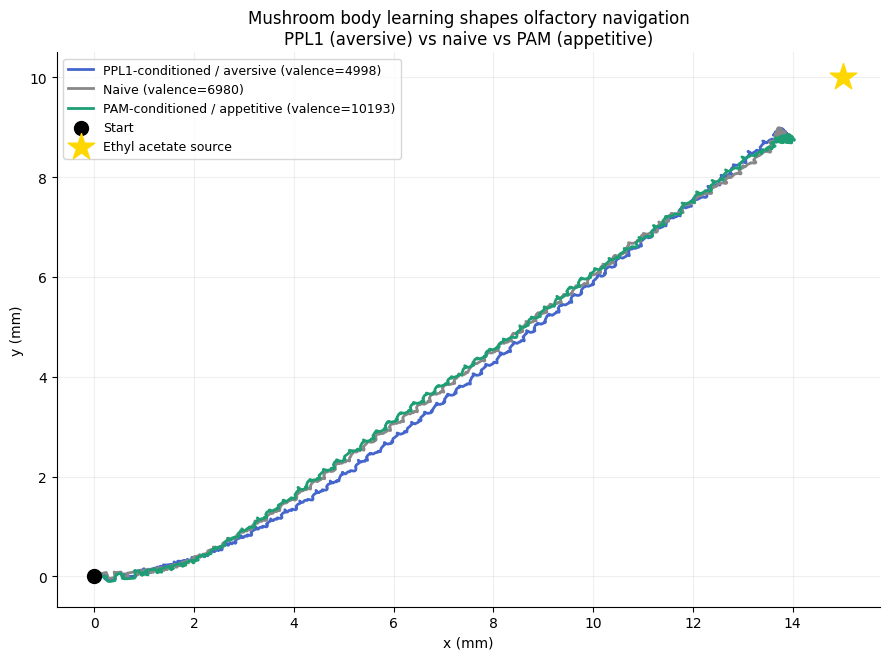


Valence summary:
  PPL1 aversive:  4998  (-28.4% vs naive)
  Naive:          6980
  PAM appetitive: 10193  (+46.0% vs naive)


In [15]:
fig, ax = plt.subplots(figsize=(9, 8))

v_av  = net_valence(ea_pn, W_ea_aversive)
v_nv  = net_valence(ea_pn, W)
v_app = net_valence(ea_pn, W_ea_appetitive)

ax.plot(pos_aversive[:, 0],   pos_aversive[:, 1],   color='#4466CC', lw=2, label=f'PPL1-conditioned / aversive (valence={v_av:.0f})')
ax.plot(pos_naive[:, 0],      pos_naive[:, 1],       color='#888888', lw=2, label=f'Naive (valence={v_nv:.0f})')
ax.plot(pos_appetitive[:, 0], pos_appetitive[:, 1],  color='#1D9E75', lw=2, label=f'PAM-conditioned / appetitive (valence={v_app:.0f})')

ax.scatter([0], [0], c='black', s=100, zorder=5, label='Start')
ax.scatter([SOURCE[0]], [SOURCE[1]], c='gold', s=400, marker='*', zorder=5, label='Ethyl acetate source')

ax.set_title('Mushroom body learning shapes olfactory navigation\nPPL1 (aversive) vs naive vs PAM (appetitive)', fontsize=12)
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.legend(fontsize=9); ax.set_aspect('equal'); ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('three_brains.png', dpi=150)
plt.show()

print(f'\nValence summary:')
print(f'  PPL1 aversive:  {v_av:.0f}  ({100*(v_av-v_nv)/v_nv:+.1f}% vs naive)')
print(f'  Naive:          {v_nv:.0f}')
print(f'  PAM appetitive: {v_app:.0f}  ({100*(v_app-v_nv)/v_nv:+.1f}% vs naive)')

## 7. Save videos

In [17]:
from IPython.display import Video, display
for path, label in [('exp_aversive.mp4','PPL1'), ('exp_naive.mp4','Naive'), ('exp_appetitive.mp4','PAM')]:
    if os.path.exists(path):
        print(label)
        display(Video(path, width=500, embed=True))

PPL1


Naive


PAM
